<h1 style="font-size: 1.6rem; font-weight: bold">ITO 5221: Intelligent Image and Video Analysis</h1>
<h1 style="font-size: 1.6rem; font-weight: bold">Module 1: Introduction to Intelligent Image and Video Analysis</h1>
<p style="margin-top: 5px; margin-bottom: 5px;">Monash University Australia</p>
<p style="margin-top: 5px; margin-bottom: 5px;">Jupyter Notebook by: Tristan Sim Yook Min</p>
References: Information Source from Monash Faculty of Information Technology

---

## **1) Image Formation**

### **Image Formation**

Image Formation is the process of taking an image of real life and mapping the three-dimensional scene and points to a two-dimensional image plane. These map the locations both geometrically and optically.

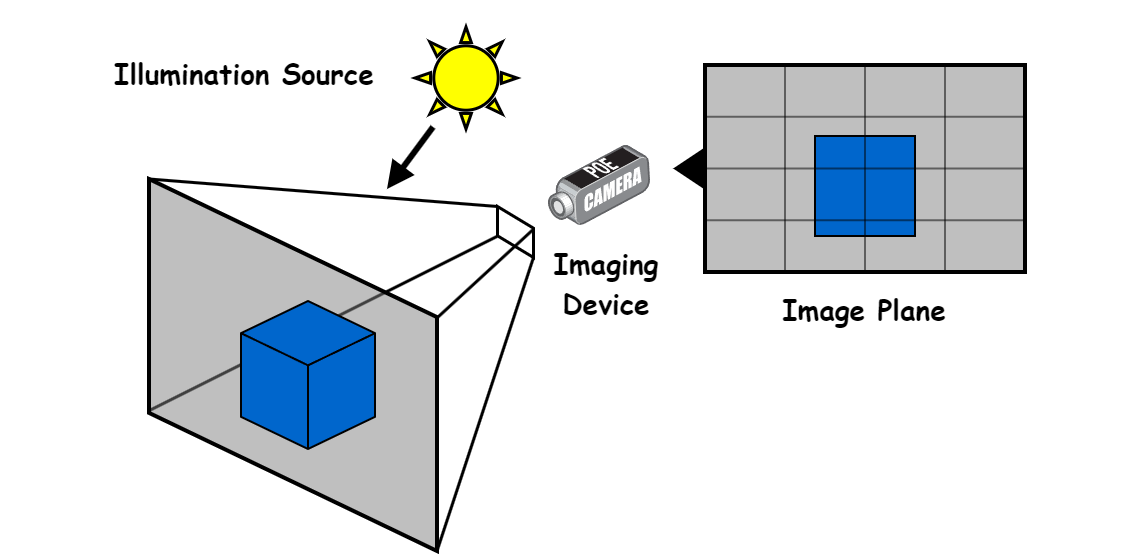

<br>

### **Digital Image**

**Goal:** Understand how continuous visual information is converted into a digital format that computers can store and process.

A digital image is made up of picture elements called **pixels**, each holding a finite numeric value representing intensity. We describe a digital image using a function $f(x, y)$, where $x$ and $y$ are spatial coordinates corresponding to the image's height and width.

But real-world scenes are continuous, to turn them into something a computer can work with, we need to convert that continuous data into discrete digital form. This happens in **two steps**:

1. **Sampling:** Divides the continuous image into a uniform grid of blocks. The sampling rate controls the **spatial resolution**: more samples means finer detail.
2. **Quantisation:** Assigns each sampled block a discrete integer intensity value. The number of quantisation levels determines how many distinct grey shades the image can represent. More levels means smoother gradients and better preservation of fine shading detail.

The continuous image hits a sensor array, and sampling chops it into a grid, while quantisation rounds each grid cell's brightness to the nearest allowed value. Together, they produce a 2D matrix of integers your digital image. A **raster image** is simply the end product of sampling and quantisation, it's the final grid of pixels stored in memory.

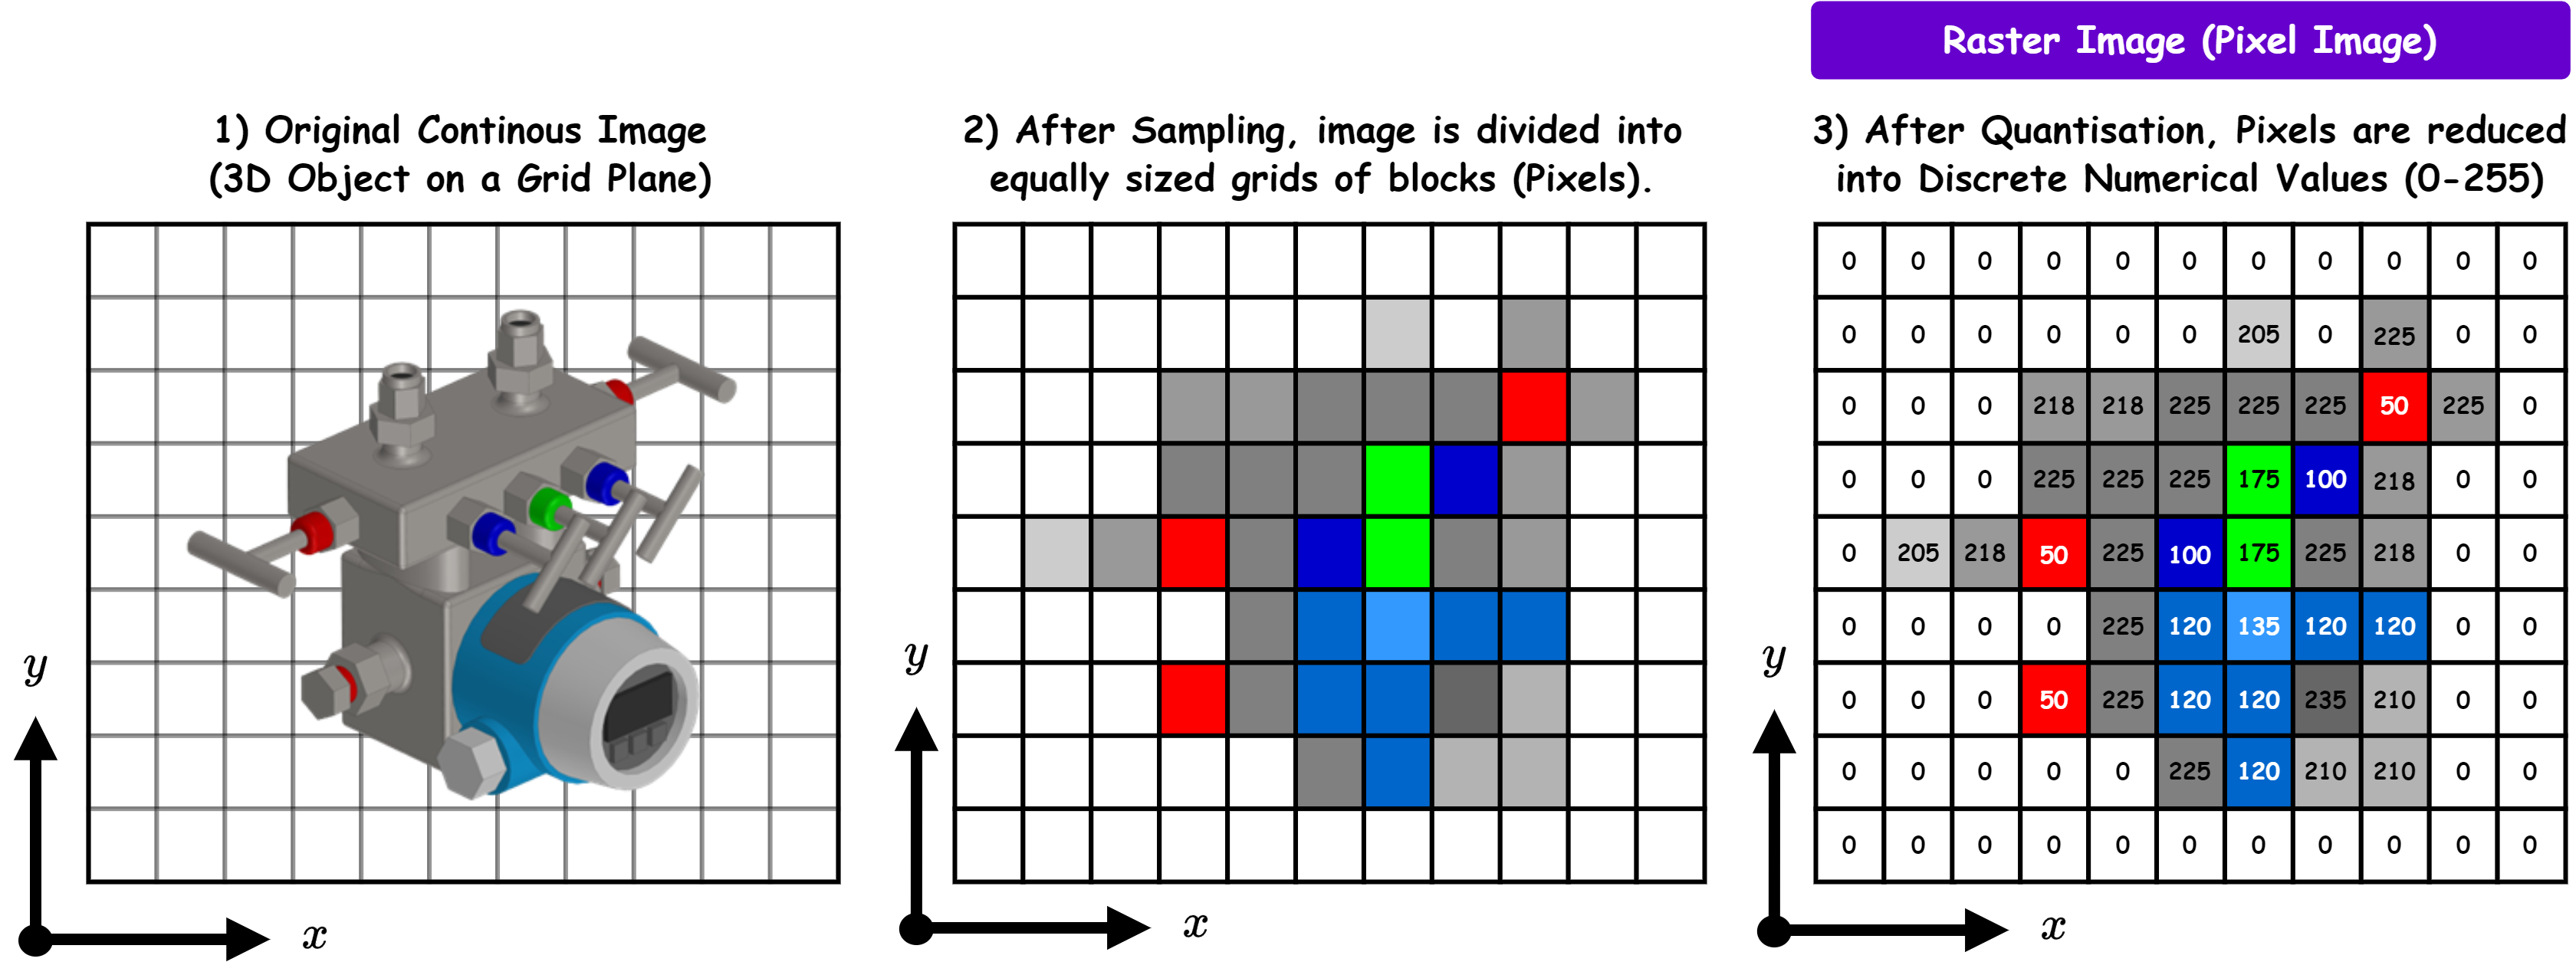

#### **The image as a matrix**

After sampling and quantisation, the image becomes a matrix of size $M \times N$:

$$
f(x, y) = \begin{bmatrix} f(0,0) & f(0,1) & \cdots & f(0,N-1) \\ f(1,0) & f(1,1) & \cdots & f(1,N-1) \\ \vdots & \vdots & \ddots & \vdots \\ f(M-1,0) & f(M-1,1) & \cdots & f(M-1,N-1) \end{bmatrix}
$$

Where:
- $M$ = number of rows (height in pixels)
- $N$ = number of columns (width in pixels)
- $f(x, y)$ = intensity value at row $x$, column $y$

Each entry is a single pixel, and its value represents brightness, typically ranging from 0 (black) to 255 (white) for an 8-bit image.

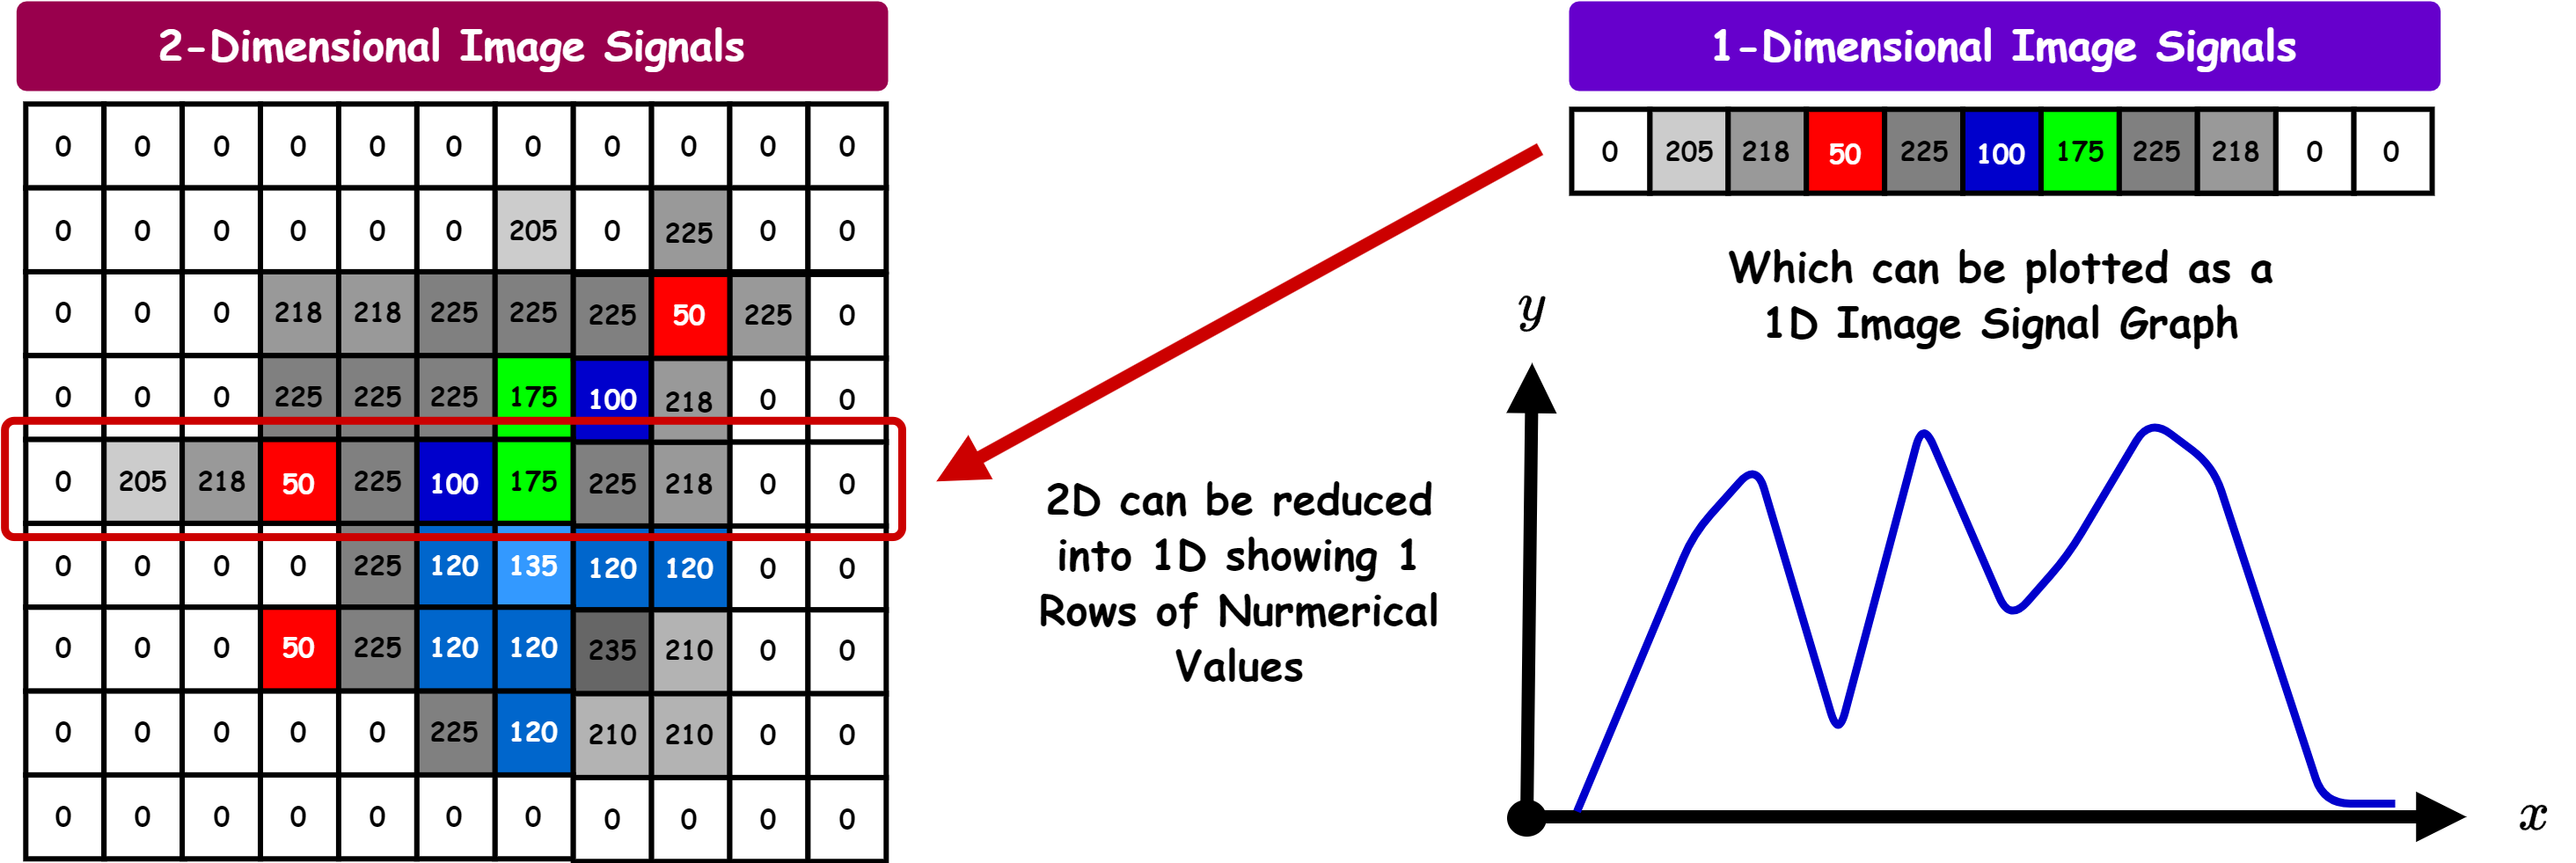

---

### **Colour Images**

A colour image is typically split into three channels **red (R)**, **green (G)**, and **blue (B)**. Each channel is essentially a separate greyscale image representing the intensity of that colour across every pixel.

To capture colour, camera sensors use a **Bayer filter**, a grid of tiny colour filters placed over the sensor pixels. Each pixel only records one colour (R, G, or B), and the full-colour image is then reconstructed through a process called **demosaicing**, which interpolates the missing colour values from neighbouring pixels.

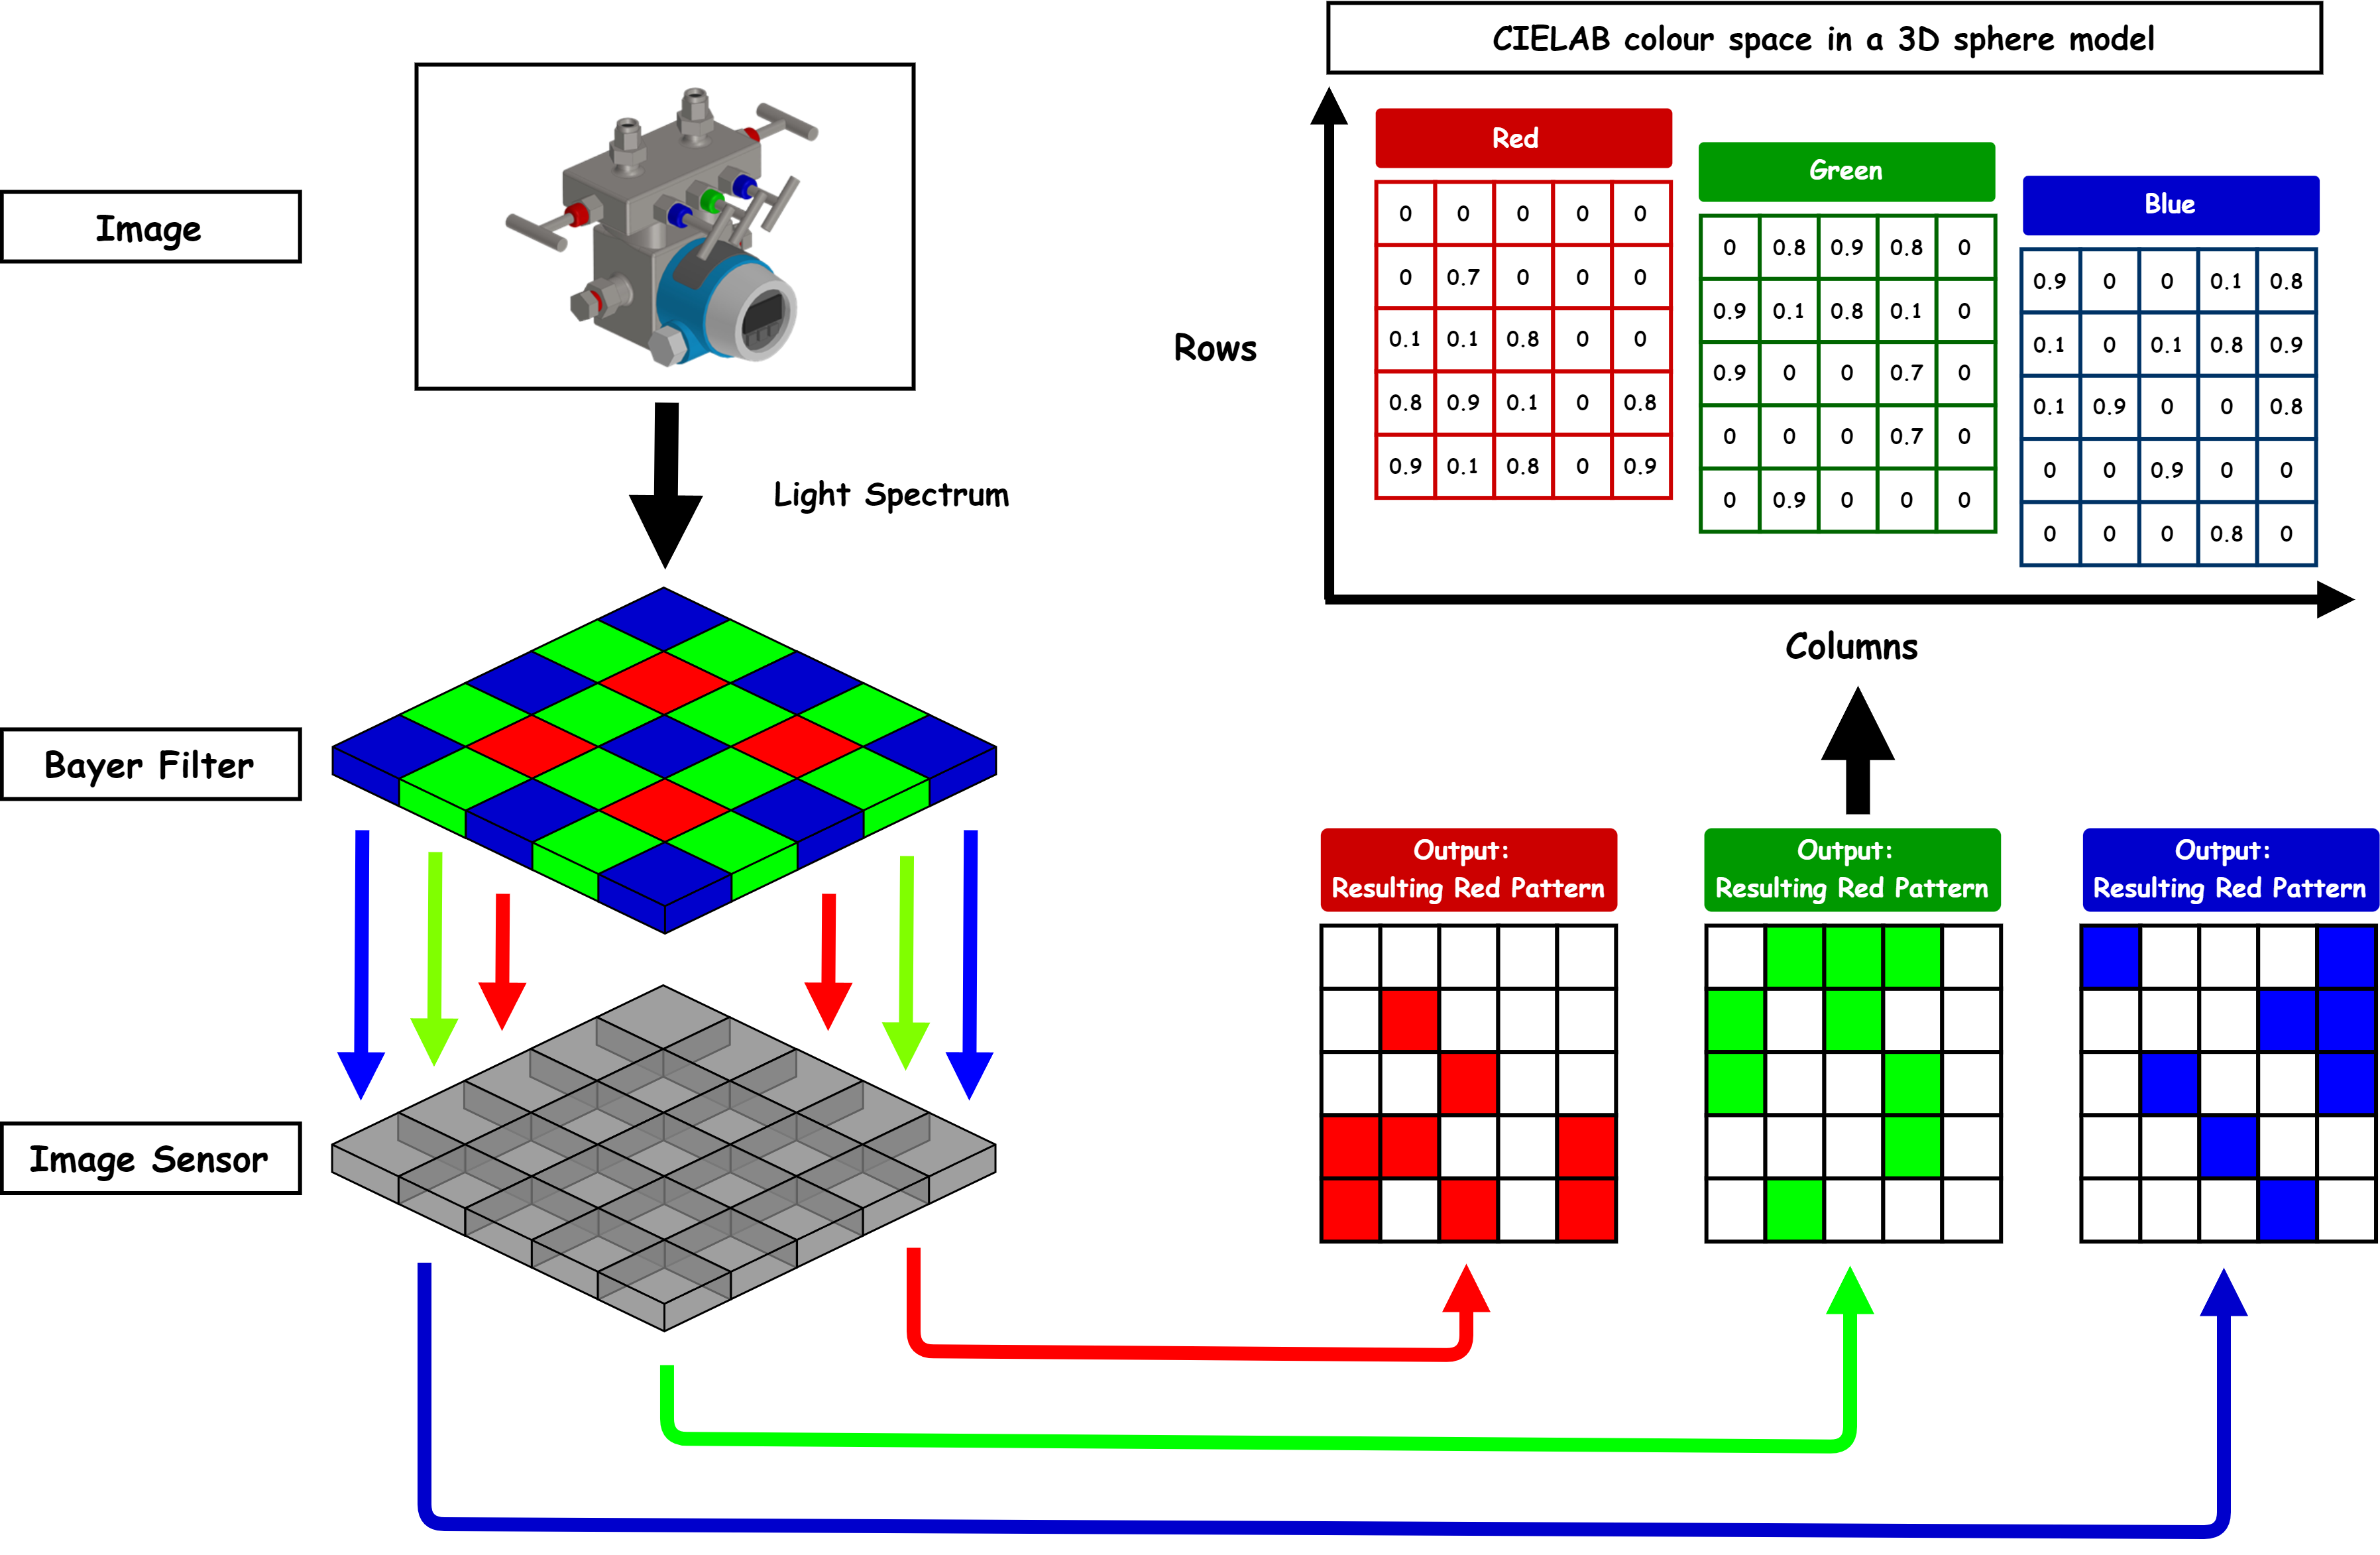

#### **Why colour matters in computer vision**
Colour information is used in many computer vision tasks, including:
- **Clustering / Segmentation:** Grouping pixels by colour to identify regions
- **Feature description:** Using colour as a distinguishing property
- **Image attribute understanding:** Inferring properties like time of day, material type, etc.

Humans can perceive a vast range of colours, so colour is a rich source of information for vision systems to exploit.

<br>

### **Light: The Electromagnetic Spectrum**

Visible light is just a small slice of the electromagnetic spectrum, the portion our eyes can detect. It spans wavelengths from roughly **380 nm** (violet) to **750 nm** (red).

#### **Attributes of light**

| Attribute | Unit | Meaning |
|---|---|---|
| Radiance | Watts | Total energy emitted by a light source |
| Luminance | Lumens | Perceived energy as observed by a viewer |
| Brightness | Subjective | How intense the light *feels* — varies from person to person |

The standard wavelength boundaries of the visible spectrum are defined by the [Commission Internationale de l'Éclairage (CIE)](https://cie.co.at/about-cie).

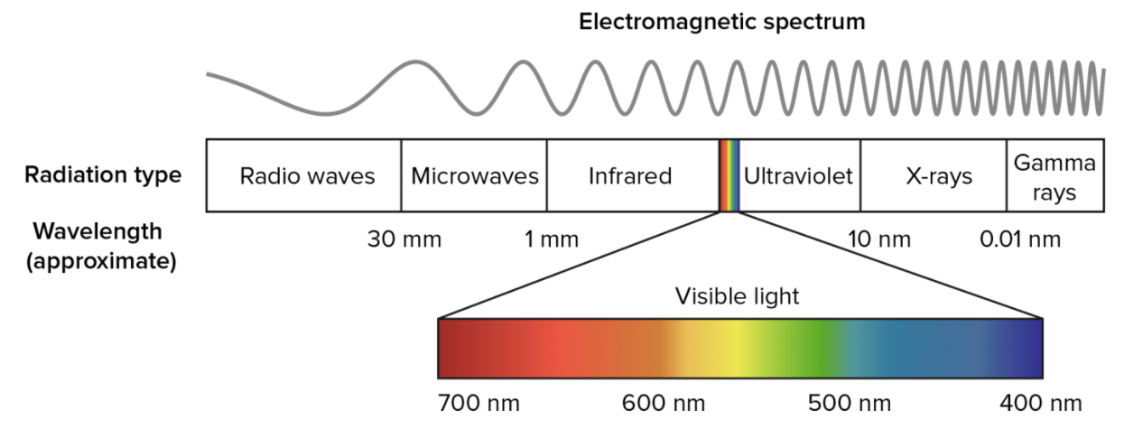

Electromagnetic spectrum (2020) <https://bit.ly/377079f>

<br>

### **Colour Perception**

Our eyes sense colour using **cone cells** roughly 7 million of them. These cones are not evenly distributed across the three colour types:

| Cone Type | Sensitivity | Proportion |
|---|---|---|
| Red (Long) | Red wavelengths | ~65% |
| Green (Medium) | Green wavelengths | ~33% |
| Blue (Short) | Blue wavelengths | ~2% |

This is why R, G, and B are called the **primary colours**, they map directly to our three types of cone receptors. Note that there are no hard boundaries between colours; the transitions are smooth and continuous. Screens and monitors generate colour by combining red, green, and blue light at varying intensities. Humans perceive colour through three properties:

| Property | What it describes |
|---|---|
| **Brightness** | The chromatic notion of intensity — how light or dark a colour appears |
| **Hue** | The dominant wavelength — what we typically call the "colour" (red, blue, orange, etc.) |
| **Saturation** | The purity of the colour — how much white light is mixed in to dilute it |

Together, **hue** and **saturation** form the **chromaticity** of light, essentially the colour information independent of brightness.

---

### **Image Handling**

Images are stored as matrices. For an $N \times M$ RGB image called `im`:

- `im(1, 1, 1)` = top-left pixel value in the R-channel
- `im(y, x, b)` = pixel located $y$ rows down, $x$ columns right, in channel $b$
- `im(N, M, 3)` = bottom-right pixel in the B-channel

So an RGB image is essentially **three stacked matrices**, one for each colour channel, forming a 3D array of size $N \times M \times 3$.

<br>

### **CIELAB Colour Space**

The **CIELAB** colour space represents colours in a 3D model using three components:

| Component | Axis | Range | Meaning |
|---|---|---|---|
| **L** (Lightness) | Vertical | 0 = black, 100 = white | How light or dark the colour is |
| **a** (Chroma) | Horizontal | +a = red, −a = green | Red-green axis |
| **b** (Chroma) | Horizontal | +b = yellow, −b = blue | Yellow-blue axis |

- **Hue** is defined by the angle in the horizontal plane between the chroma vectors
- The centre of the space represents **neutral grey**

This model is designed to be **perceptually uniform**, equal distances in the space correspond to roughly equal perceived colour differences.

<br>

### **Image as a Function**

An image can be thought of as a function $f : \mathbb{R}^2 \rightarrow \mathbb{R}$, where $f(x, y)$ returns the intensity at spatial location $(x, y)$.

For a 3-channel RGB image, this becomes a **vector-valued function**:

$$f(x, y) = [r(x, y), \; g(x, y), \; b(x, y)]$$

Each channel function returns the intensity for red, green, or blue at that pixel location.

<br>

### **Point Operators**

The simplest image operations work on **individual pixels** independently. The general form is:

$$g(x) = a \cdot f(x) + b$$

Where:
- $f(x)$ = input pixel value
- $g(x)$ = output pixel value
- $a > 0$ = **gain** (controls **contrast**)
- $b$ = **bias** (controls **brightness**)

#### **Common point operations**

| Operation | Formula | Effect |
|---|---|---|
| Darken | $x - 128$ | Subtracts from each pixel → much darker image |
| Lighten | $x + 128$ | Adds to each pixel → washed-out, overexposed look |
| Lower contrast | $x / 2$ | Halves pixel values → dull, greyish appearance |
| Raise contrast | $x \times 2$ | Doubles pixel values → vivid, high-contrast look |
| Invert | $255 - x$ | Flips all values → produces a negative effect |

The key idea is that each pixel is transformed **independently**, the operation doesn't care about neighbouring pixels.

<br>

### **Image Noise**

Noise refers to unwanted random variations in pixel values that degrade image quality. Common types include:

| Noise Type | Description |
|---|---|
| **Salt and pepper** | Random black and white pixels scattered across the image |
| **Impulse** | Random white pixels appearing in the image |
| **Gaussian** | Intensity variations drawn from a Gaussian (normal) distribution — the most common type |

#### **Noise removal by averaging**

A popular denoising technique is **averaging** over neighbouring pixels. The idea relies on two assumptions:
1. Neighbouring pixels tend to have **similar values**
2. Noise is **independent** from pixel to pixel

So by averaging a pixel with its neighbours, the true signal reinforces itself while the random noise cancels out. This is essentially a simple **filtering operation** applied across the image.

---

## **Image Filtering**

In image processing, **filtering** is a technique that modifies pixel values based on their local neighbourhood. A small matrix called a **filter** (or **kernel/mask**) defines how to combine a pixel's value with its neighbours to produce a new value.

Filtering is used to:
- **Enhance** images (denoising, resizing, sharpening)
- **Extract information** (textures, edges, gradients)
- **Detect patterns** (template matching)

<br>

### **1) Averaging in 2D (Box Filter)**

The simplest filter is the **box filter** — it replaces each pixel with the average of all pixels in its neighbourhood. This smooths the image and reduces noise.

For a window of size $(2k+1) \times (2k+1)$, the averaging formula is:

$$G[i, j] = \frac{1}{(2k+1)^2} \sum_{u=-k}^{k} \sum_{v=-k}^{k} F[i+u, \; j+v]$$

Where:
- $F[i, j]$ = the original image pixel at row $i$, column $j$
- $G[i, j]$ = the output (filtered) pixel
- $k$ = how far the window extends from the centre pixel
- $(2k+1)^2$ = total number of pixels in the window — each gets **equal weight**

The double sum loops over every pixel in the neighbourhood around $F[i, j]$, adds them all up, and divides by the total count to get the average.

#### **What it does visually**
Sharp edges in the original image $f(x,y)$ become gradual transitions in the output $g(x,y)$. The white rectangle with crisp boundaries turns into a smooth gradient — noise is removed, but edges get blurred too.

<br>

### **2) Correlation Filtering (Generalised)**

The box filter gives **equal weight** to every neighbour. But what if some neighbours should matter more than others? We generalise by introducing a **weight function** $H[u, v]$:

$$G[i, j] = \sum_{u=-k}^{k} \sum_{v=-k}^{k} H[u, v] \; F[i+u, \; j+v]$$

Where:
- $H[u, v]$ = the filter kernel — a matrix of weights that determines how much each neighbouring pixel contributes
- The kernel slides across the image, computing a weighted sum at every position

This is called **cross-correlation** — the filter is placed on top of each pixel location, element-wise multiplied with the image, and summed.

<br>

### **3) Gaussian Smoothing Filter**

The box filter treats all neighbours equally, which can **blur edges** too aggressively. The **Gaussian filter** improves on this by giving **more weight to central pixels** and less to those further away.

The weight function follows a 2D Gaussian distribution:

$$h(u, v) = \frac{1}{2\pi\sigma^2} \; e^{-\frac{u^2 + v^2}{\sigma^2}}$$

Where:
- $\sigma$ = standard deviation — controls how wide the blur is
- Pixels near the centre get high weight
- Pixels far from the centre get weight close to zero

The result is a **smoother, more natural blur** that preserves edge information better than simple averaging. This is why Gaussian smoothing is preferred in most image analysis tasks.

<br>

### **4) Convolution**

**Convolution** is almost identical to correlation, with one key difference: you **flip the filter** in both dimensions (bottom-to-top, right-to-left) before applying it.

$$G[i, j] = \sum_{u=-k}^{k} \sum_{v=-k}^{k} H[u, v] \; F[i-u, \; j-v]$$

Notice the subtraction ($i - u$, $j - v$) instead of addition — this is the flip in action.

In shorthand notation:

$$G = H \star F$$

Where $\star$ denotes the **convolution operator**.

#### **Correlation vs Convolution**
- **Correlation**: slide the filter as-is across the image → $F[i+u, j+v]$
- **Convolution**: flip the filter first, then slide → $F[i-u, j-v]$

For **symmetric filters** (like Gaussian), flipping changes nothing — so correlation and convolution produce the same result. The distinction matters for asymmetric filters.

---

## **Edge Detection**

### **Histograms**

A **histogram** is a visual representation of how frequently each intensity value appears in a greyscale image. It looks like a bar graph — the x-axis represents pixel intensity (0–255) and the y-axis represents how many pixels have that intensity.

Histograms are widely used in **low-level image analysis** for tasks like contrast adjustment, thresholding, and understanding the overall brightness distribution of an image.

<br>

### **Edge Detection**

An **edge** is a location in the image where intensity changes rapidly. Edges typically correspond to object boundaries, surface markings, or changes in depth or illumination.

#### **Why edges matter**
The goal of edge detection is to identify and understand the structure of objects in a scene. When you apply an edge detector, most of the image becomes black, with white lines highlighting where sharp transitions occur.

#### **Derivatives and edges**

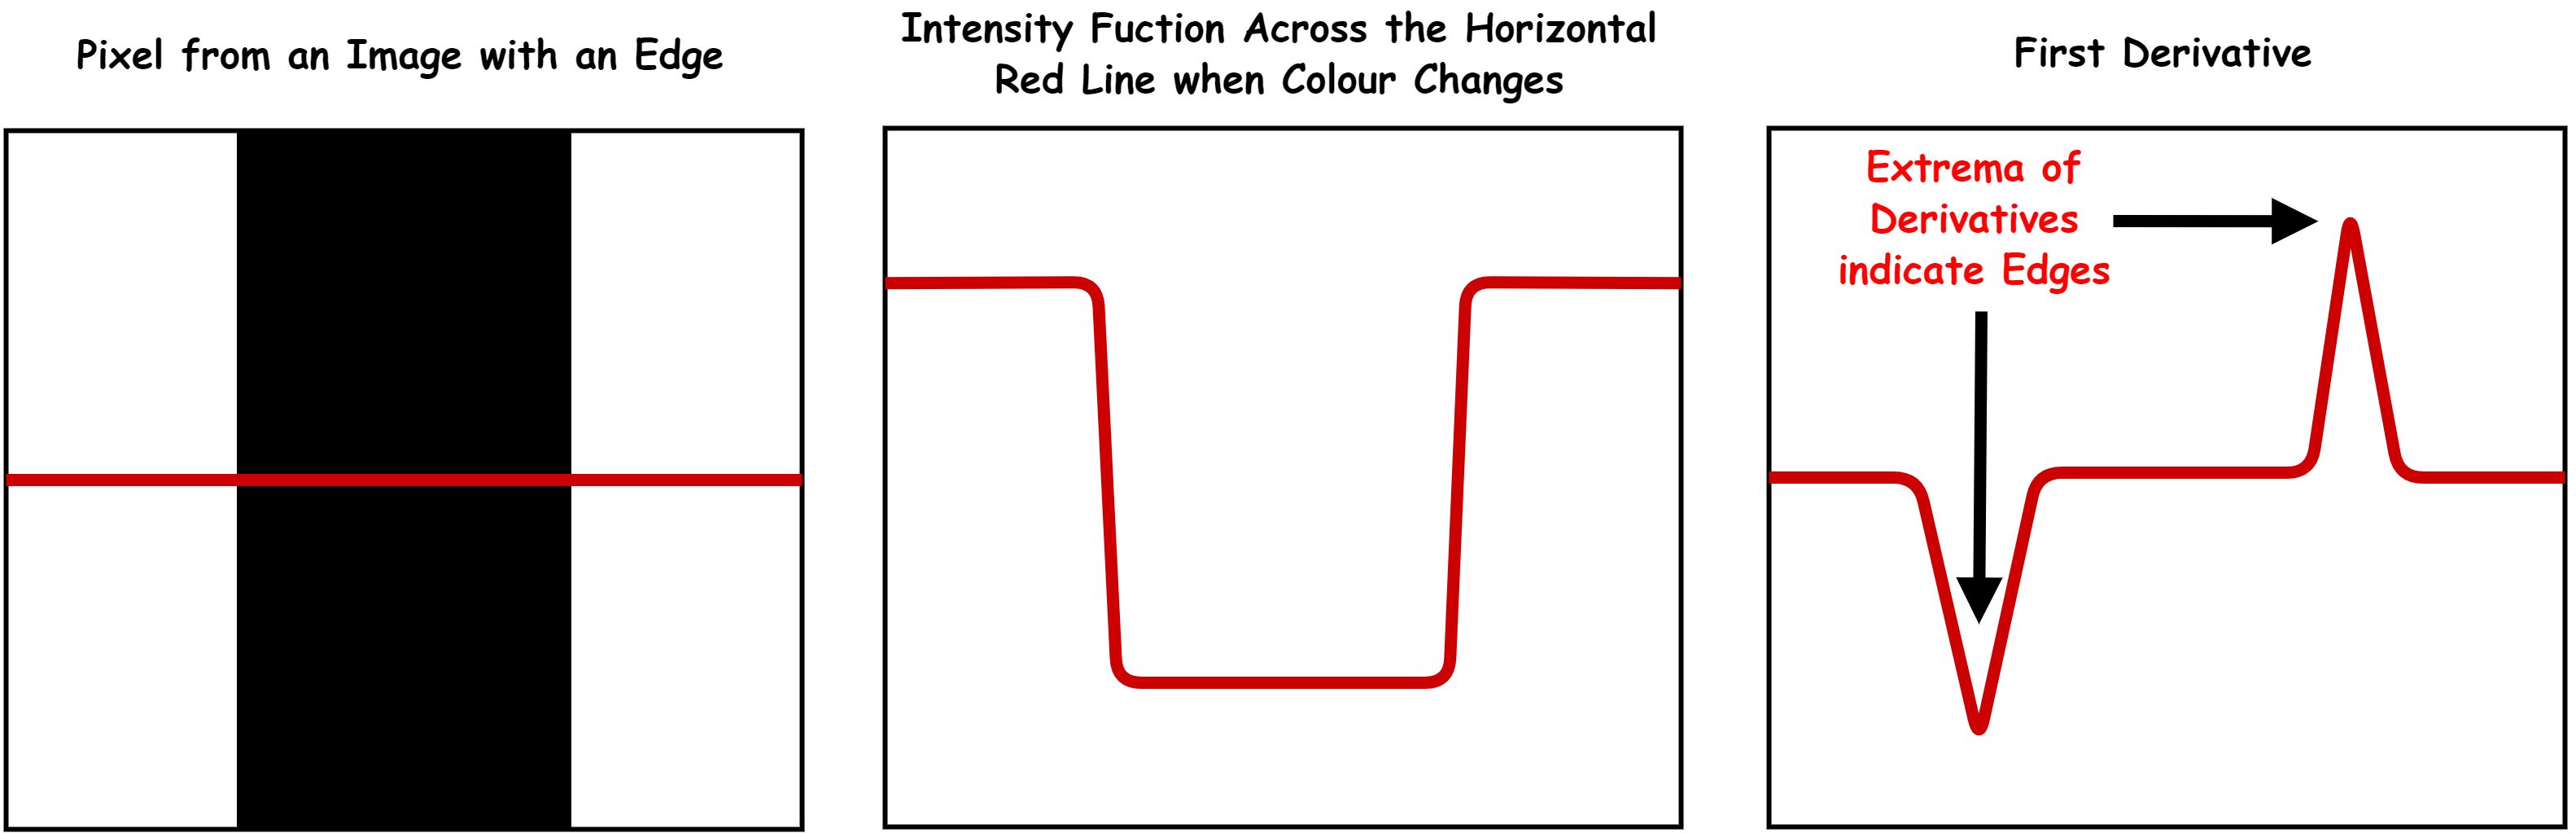

Since an edge is a rapid change in intensity, we can detect it using **derivatives**, the derivative measures the rate of change.

If you take a horizontal scanline across an image and plot the intensity, edges appear as steep slopes. The **first derivative** of that intensity function will spike at those locations, edges correspond to the **extrema (peaks and valleys)** of the derivative.

#### **Computing derivatives on discrete images**
For a continuous 2D function $f(x, y)$, the partial derivative with respect to $x$ is:

$$\frac{\partial f(x, y)}{\partial x} = \lim_{\varepsilon \to 0} \frac{f(x + \varepsilon, \; y) - f(x, \; y)}{\varepsilon}$$

But images are discrete, there's no infinitely small $\varepsilon$. So we approximate using **finite differences** with a step size of 1 pixel:

$$\frac{\partial f(x, y)}{\partial x} \approx f(x + 1, \; y) - f(x, \; y)$$

This is simply: *subtract each pixel from its right neighbour*. The result highlights horizontal intensity changes (vertical edges).

<br>

### **The Noise Problem**

Taking the derivative of a noisy image **amplifies the noise**. If the signal $f(x)$ contains random fluctuations, the derivative $\frac{d}{dx}f(x)$ turns those small fluctuations into large spikes, the true edge gets lost in the noise.

This means we can't just blindly differentiate a noisy image and expect clean edges.

<br>

### **Derivative Theorem of Convolution**

The solution is to **smooth first, then differentiate**. But there's a useful shortcut, the **derivative theorem of convolution**:

$$\frac{\partial}{\partial x}(h \star f) = \left(\frac{\partial}{\partial x} h\right) \star f$$

This says: differentiating a smoothed signal is the same as convolving with the derivative of the smoothing kernel. Instead of two operations (smooth then differentiate), we can do it in **one step** by convolving with the derivative of the Gaussian.

#### **What this looks like in practice**
1. $f$: the noisy input signal (edge buried in noise)
2. $\frac{\partial}{\partial x} h$: the derivative of the Gaussian kernel (looks like a wave with a positive and negative lobe)
3. $\left(\frac{\partial}{\partial x} h\right) \star f$: the result: a clean peak exactly where the edge is, with the noise suppressed

<br>

### **Canny Edge Detector**

The **Canny edge detector** is one of the most widely used edge detection algorithms. It follows four steps:

1. **Smooth the image** with a Gaussian filter — removes noise so derivatives are clean
2. **Compute gradient magnitude and orientation** — find how strong and in which direction the intensity changes at every pixel
3. **Non-maximum suppression** — thin the wide gradient "ridges" down to single-pixel-width edges, keeping only the local maxima along the gradient direction
4. **Linking and thresholding (hysteresis)** — apply two thresholds (high and low): the high threshold starts edge curves at strong edges, and the low threshold continues them through weaker connected edges

This two-threshold approach avoids the problem of a single threshold — too high misses weak edges, too low includes noise. Hysteresis gives you the best of both.

<br>